First 5 rows:
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680

--- Descriptive Statistics ---
Mean:
 Quantity            4.78
Price           25808.51
Total_Sales    123650.48
dtype: float64

Median:
 Quantity           5.0
Price          24192.0
Total_Sales    97955.5
dtype: float64

Mode:
 Quantity          4.0
Price          1308.0
Total_Sales    6540.0
Name: 0, dtype: float64

Standard Deviation:
 Quantity            2.588163
Price           13917.630242
Total_Sales    100161.085275
dtype: float64

--- Distribution Analysis ---


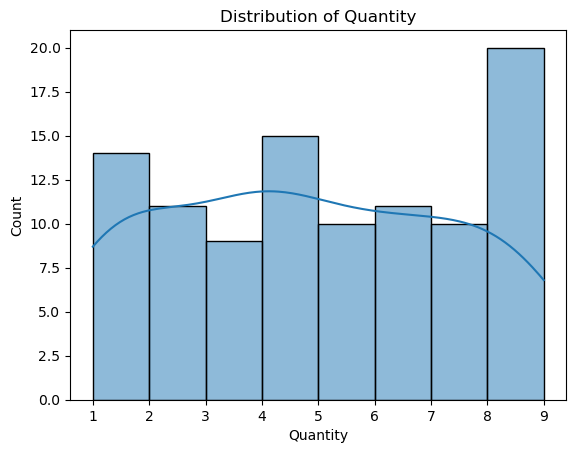

Quantity → Shapiro p-value: 0.0001
  Not Normally Distributed


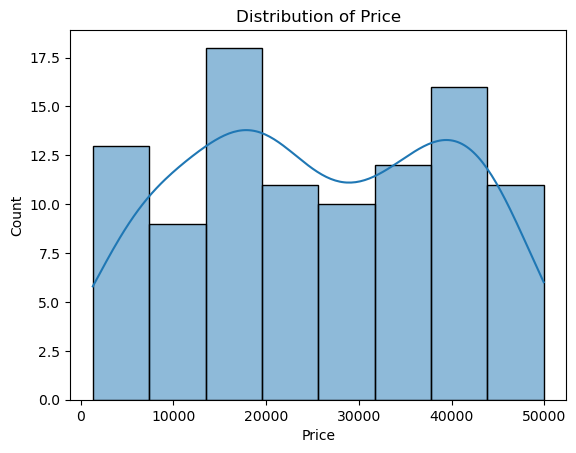

Price → Shapiro p-value: 0.0006
  Not Normally Distributed


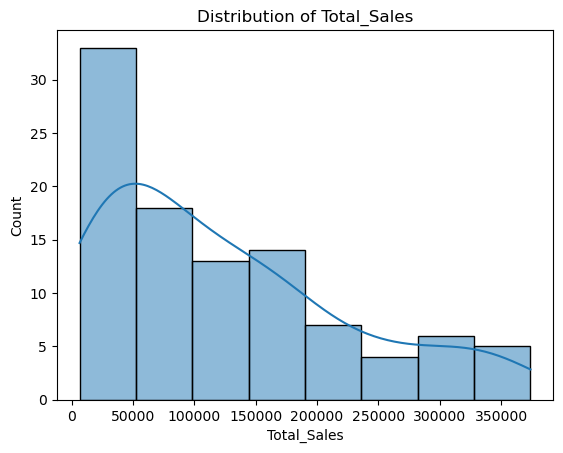

Total_Sales → Shapiro p-value: 0.0000
  Not Normally Distributed

--- Correlation Analysis ---
             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000


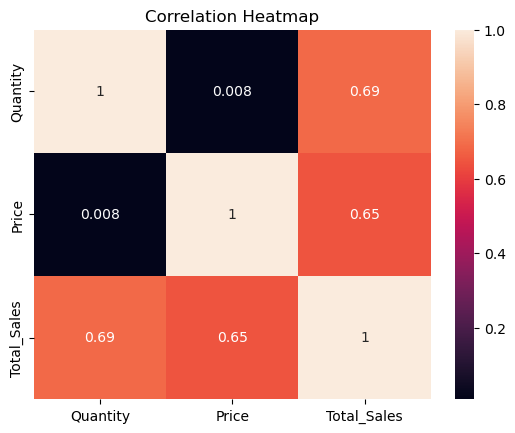


--- Hypothesis Testing ---
Columns in dataset: ['date', 'product', 'quantity', 'price', 'customer_id', 'region', 'total_sales']

One-sample T-test p-value: 0.0000

Regions found: ['East' 'North' 'West' 'South']
Independent T-test (East vs North) p-value: 0.7227
ANOVA p-value: 0.0972

Hypothesis Testing Complete ✅

--- Confidence Interval (95%) ---
Mean Sales: 123650.48
95% CI: (103776.35, 143524.61)
Margin of Error: ±19874.13

--- Regression Analysis ---
R-squared: 0.8839
Coefficients: [2.64308402e+04 4.61062190e+00]
Intercept: -121682.22


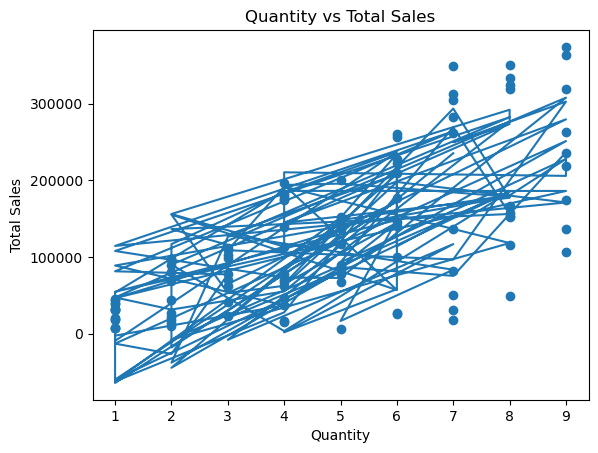


--- Business Insights ---
Correlation (Quantity vs Total Sales): 0.69
Correlation (Price vs Total Sales): 0.65

Insights:
• Quantity → Moderate relationship → Sales increase with quantity
• Price → Moderate relationship → Sales influenced by pricing

Recommendations:
✔ Monitor customer demand and adjust inventory accordingly

Analysis Complete ✅


In [1]:
# ==============================
# 📦 Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, ttest_1samp, ttest_ind, f_oneway, t
from sklearn.linear_model import LinearRegression
# ==============================
# 📂 Load Dataset
# ==============================
df = pd.read_csv("sales_data.csv")

print("First 5 rows:")
print(df.head())
# ==============================
# 📊 1. Descriptive Statistics
# ==============================
print("\n--- Descriptive Statistics ---")
print("Mean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nMode:\n", df.mode(numeric_only=True).iloc[0])
print("\nStandard Deviation:\n", df.std(numeric_only=True))
# ==============================
# 📊 2. Distribution Analysis
# ==============================
print("\n--- Distribution Analysis ---")

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

    stat, p = shapiro(df[col])
    print(f"{col} → Shapiro p-value: {p:.4f}")
    if p > 0.05:
        print("  Looks Normally Distributed")
    else:
        print("  Not Normally Distributed")
# ==============================
# 🔗 3. Correlation Analysis
# ==============================
print("\n--- Correlation Analysis ---")

corr = df.corr(numeric_only=True)
print(corr)

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()
print("\n--- Hypothesis Testing ---")

df = pd.read_csv("sales_data.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("Columns in dataset:", df.columns.tolist())

# ==============================
# ✅ One-Sample T-Test
# ==============================
if 'total_sales' in df.columns:

    sales_data = df['total_sales'].dropna()

    if len(sales_data) > 1:
        t_stat, p_val = ttest_1samp(sales_data, popmean=40000)
        print(f"\nOne-sample T-test p-value: {p_val:.4f}")
    else:
        print("Not enough data for One-sample T-test")

# ==============================
# ✅ Independent T-Test + ANOVA
# ==============================
if 'total_sales' in df.columns and 'region' in df.columns:

    df_clean = df[['total_sales', 'region']].dropna()

    regions = df_clean['region'].unique()
    print("\nRegions found:", regions)

    if len(regions) >= 2:

        # Independent T-test
        group1 = df_clean[df_clean['region'] == regions[0]]['total_sales']
        group2 = df_clean[df_clean['region'] == regions[1]]['total_sales']

        if len(group1) > 1 and len(group2) > 1:
            t_stat, p_val = ttest_ind(group1, group2)
            print(f"Independent T-test ({regions[0]} vs {regions[1]}) p-value: {p_val:.4f}")
        else:
            print("Not enough data for Independent T-test")

        # ANOVA
        groups = [g['total_sales'].dropna() for _, g in df_clean.groupby('region')]
        groups = [g for g in groups if len(g) > 1]

        if len(groups) > 1:
            f_stat, p_val = f_oneway(*groups)
            print(f"ANOVA p-value: {p_val:.4f}")
        else:
            print("Not enough valid groups for ANOVA")

    else:
        print("Not enough regions for comparison")

print("\nHypothesis Testing Complete ✅")
# ==============================
# 📐 5. Confidence Interval
# ==============================
import numpy as np
from scipy.stats import t

print("\n--- Confidence Interval (95%) ---")

# Use correct column name
if 'total_sales' in df.columns:

    sales_data = df['total_sales'].dropna()
    n = len(sales_data)

    if n > 1:
        mean = np.mean(sales_data)
        std = np.std(sales_data, ddof=1)

        confidence = 0.95
        t_crit = t.ppf((1 + confidence) / 2, df=n-1)

        margin_error = t_crit * (std / np.sqrt(n))

        lower = mean - margin_error
        upper = mean + margin_error

        print(f"Mean Sales: {mean:.2f}")
        print(f"95% CI: ({lower:.2f}, {upper:.2f})")
        print(f"Margin of Error: ±{margin_error:.2f}")
    else:
        print("Not enough data to compute confidence interval")

else:
    print("Column 'total_sales' not found")
# ==============================
# 📈 6. Regression Analysis
# ==============================
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

print("\n--- Regression Analysis ---")

# Clean column names (just in case)
df.columns = df.columns.str.strip().str.lower()

# ==============================
# ✅ Use correct columns
# ==============================
if all(col in df.columns for col in ['quantity', 'price', 'total_sales']):

    df_clean = df[['quantity', 'price', 'total_sales']].dropna()

    X = df_clean[['quantity', 'price']]   # Multiple regression
    y = df_clean['total_sales']

    model = LinearRegression()
    model.fit(X, y)

    r2 = model.score(X, y)

    print(f"R-squared: {r2:.4f}")
    print(f"Coefficients: {model.coef_}")
    print(f"Intercept: {model.intercept_:.2f}")

    # ==============================
    # 📊 Visualization (simple 2D)
    # ==============================
    plt.figure()
    plt.scatter(df_clean['quantity'], y)
    plt.plot(df_clean['quantity'], model.predict(X))
    plt.title("Quantity vs Total Sales")
    plt.xlabel("Quantity")
    plt.ylabel("Total Sales")
    plt.show()

else:
    print("Required columns not found for regression")
# ==============================
# 💡 7. Business Insights
# ==============================
print("\n--- Business Insights ---")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# ==============================
# ✅ Correlation Analysis
# ==============================
if all(col in df.columns for col in ['quantity', 'price', 'total_sales']):

    corr_q = df['quantity'].corr(df['total_sales'])
    corr_p = df['price'].corr(df['total_sales'])

    print(f"Correlation (Quantity vs Total Sales): {corr_q:.2f}")
    print(f"Correlation (Price vs Total Sales): {corr_p:.2f}")

    # ==============================
    # ✅ Interpretation
    # ==============================
    def interpret(corr):
        if corr > 0.7:
            return "Strong positive relationship"
        elif corr > 0.3:
            return "Moderate relationship"
        else:
            return "Weak relationship"

    print("\nInsights:")

    print(f"• Quantity → {interpret(corr_q)} → Sales increase with quantity")
    print(f"• Price → {interpret(corr_p)} → Sales influenced by pricing")

    # ==============================
    # 💡 Business Recommendations
     # ==============================
    print("\nRecommendations:")

    if corr_q > 0.7:
        print("✔ Focus on increasing product quantity (sales volume strategy)")

    if corr_p > 0.7:
        print("✔ Pricing strongly impacts revenue → optimize pricing strategy")

    print("✔ Monitor customer demand and adjust inventory accordingly")

else:
    print("Required columns not found for business insights")

print("\nAnalysis Complete ✅")